# Workshop 2 — YOLOv8 Fine-tuning & Deployment
**Materia:** Inteligencia Artificial  
**Dataset:** [Logistics (Roboflow Universe)](https://universe.roboflow.com/large-benchmark-datasets/logistics-sz9jr/browse)

## Part 0 — Setup

In [1]:
%pip install "ultralytics==8.*" "litserve==0.*" "numpy==1.26.*" "scikit-learn==1.3.2.*" fastapi uvicorn pillow opencv-python supervision roboflow -q

Note: you may need to restart the kernel to use updated packages.


## Part 1 — Dataset Download

In [2]:
from roboflow import Roboflow

rf = Roboflow(api_key="p5xHy6F3xuJnMvBZQkIA")  # reemplaza con tu API key
project = rf.workspace("large-benchmark-datasets").project("logistics-sz9jr")
dataset = project.version(2).download("yolov8", location="datasets/logistics")
print("Dataset path:", dataset.location)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to datasets/logistics in yolov8:: 100%|██████████| 189460/189460 [00:43<00:00, 4399.43it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/teamspace/studios/this_studio/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Dataset path: /teamspace/studios/this_studio/Workshops-AI/Workshop 2/datasets/logistics


## Part 2 — Fine-tune YOLOv8s

**Decisión de modelo:** Se usa `yolov8s` en lugar de `yolov8n` porque el dataset de logística contiene objetos pequeños y variados (cajas, pallets, etiquetas). El modelo `s` (small) tiene ~11M parámetros vs ~3M del `n`, lo que le da mayor capacidad de representación sin ser prohibitivo en tiempo de entrenamiento.

In [3]:
from ultralytics import YOLO

model = YOLO("yolov8s.pt")  # yolov8s: mejor balance capacidad/velocidad para objetos pequeños

results = model.train(data="datasets/logistics/data.yaml", 
    epochs=30, 
    imgsz=640, 
    batch=16, 
    project="runs/logistics", 
    name="y8s",
    exist_ok=True
)

print("Best weights:", results.save_dir)

Ultralytics 8.4.33 🚀 Python-3.12.11 torch-2.8.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=datasets/logistics/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=y8s, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0,

## Part 3 — Validación y Métricas

In [6]:
from ultralytics import YOLO
import pandas as pd

best_model = YOLO("/teamspace/studios/this_studio/Workshops-AI/Workshop 2/runs/detect/runs/logistics/y8s/weights/best.pt")

# --- Validación en val set ---
val_metrics = best_model.val(data="datasets/logistics/data.yaml", split="val")

print("=== VAL SET ===")
print(f"mAP@0.50:       {val_metrics.box.map50:.4f}")
print(f"mAP@0.50:0.95:  {val_metrics.box.map:.4f}")
print(f"Precision:      {val_metrics.box.mp:.4f}")
print(f"Recall:         {val_metrics.box.mr:.4f}")

# F1 = 2 * P * R / (P + R)
P = val_metrics.box.mp
R = val_metrics.box.mr
F1 = 2 * P * R / (P + R + 1e-9)
print(f"F1 Score:       {F1:.4f}")

Ultralytics 8.4.33 🚀 Python-3.12.11 torch-2.8.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 73 layers, 11,133,324 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 842.4±313.6 MB/s, size: 42.7 KB)
val: Scanning /teamspace/studios/this_studio/Workshops-AI/Workshop 2/datasets/logistics/valid/labels.cache... 18988 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 18988/18988 4.4Git/s 0.0s
val: /teamspace/studios/this_studio/Workshops-AI/Workshop 2/datasets/logistics/valid/images/-Docker-1-Do_jpg.rf.5c00af35cf477fec60189674679ea214.jpg: 2 duplicate labels removed
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1187/1187 4.9it/s 4:03<0.2s
                   all      18988      72322      0.781      0.716      0.774      0.579
               barcode        476        522      0.803      0.883       0.86      0.636
                   car       1953       2626      0.771      0.784  

In [7]:
# --- Validación en test set ---
test_metrics = best_model.val(data="datasets/logistics/data.yaml", split="test")

print("=== TEST SET ===")
print(f"mAP@0.50:       {test_metrics.box.map50:.4f}")
print(f"mAP@0.50:0.95:  {test_metrics.box.map:.4f}")
print(f"Precision:      {test_metrics.box.mp:.4f}")
print(f"Recall:         {test_metrics.box.mr:.4f}")

P_t = test_metrics.box.mp
R_t = test_metrics.box.mr
F1_t = 2 * P_t * R_t / (P_t + R_t + 1e-9)
print(f"F1 Score:       {F1_t:.4f}")

Ultralytics 8.4.33 🚀 Python-3.12.11 torch-2.8.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 59.9±8.0 MB/s, size: 49.3 KB)
val: Scanning /teamspace/studios/this_studio/Workshops-AI/Workshop 2/datasets/logistics/test/labels... 9525 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 9525/9525 1.3Kit/s 7.5s<0.0s
val: New cache created: /teamspace/studios/this_studio/Workshops-AI/Workshop 2/datasets/logistics/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 596/596 4.8it/s 2:04<0.2s
                   all       9525      36721      0.776      0.712      0.769      0.579
               barcode        272        283      0.828      0.922      0.877      0.653
                   car       1000       1379      0.792      0.777      0.855       0.71
         cardboard box        443       4995      0.879      0.811      0.889      0.768
                  fire       1133       279

In [8]:
# --- AP y AR por clase ---
names = best_model.names
ap_per_class = val_metrics.box.ap_class_index  # índices de clases
ap50_per_class = val_metrics.box.ap50          # AP@0.50 por clase
ap_per_class_vals = val_metrics.box.ap         # AP@0.50:0.95 por clase

print("\n=== AP por clase (val) ===")
for idx, ap50, ap in zip(ap_per_class, ap50_per_class, ap_per_class_vals):
    print(f"  {names[idx]:20s}  AP@50={ap50:.4f}  AP@50:95={ap:.4f}")


=== AP por clase (val) ===
  barcode               AP@50=0.8596  AP@50:95=0.6360
  car                   AP@50=0.8563  AP@50:95=0.7246
  cardboard box         AP@50=0.8982  AP@50:95=0.7740
  fire                  AP@50=0.4970  AP@50:95=0.2538
  forklift              AP@50=0.9284  AP@50:95=0.7123
  freight container     AP@50=0.5806  AP@50:95=0.4392
  gloves                AP@50=0.7749  AP@50:95=0.5546
  helmet                AP@50=0.7529  AP@50:95=0.4708
  ladder                AP@50=0.6379  AP@50:95=0.4488
  license plate         AP@50=0.6189  AP@50:95=0.5179
  person                AP@50=0.8225  AP@50:95=0.5757
  qr code               AP@50=0.9024  AP@50:95=0.7264
  road sign             AP@50=0.4397  AP@50:95=0.3586
  safety vest           AP@50=0.9053  AP@50:95=0.6569
  smoke                 AP@50=0.6824  AP@50:95=0.3903
  traffic cone          AP@50=0.8917  AP@50:95=0.7017
  traffic light         AP@50=0.9301  AP@50:95=0.6432
  truck                 AP@50=0.9404  AP@50:95=0.8495


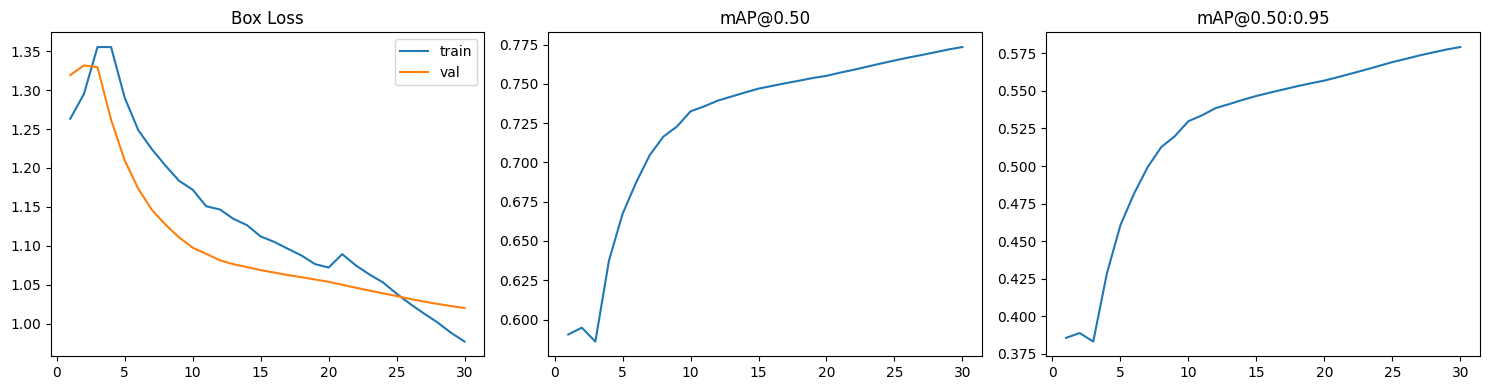

In [12]:
# --- Curvas de entrenamiento ---
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd

results_csv = pd.read_csv("/teamspace/studios/this_studio/Workshops-AI/Workshop 2/runs/detect/runs/logistics/y8s/results.csv")
results_csv.columns = results_csv.columns.str.strip()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(results_csv["epoch"], results_csv["train/box_loss"], label="train")
axes[0].plot(results_csv["epoch"], results_csv["val/box_loss"], label="val")
axes[0].set_title("Box Loss")
axes[0].legend()

axes[1].plot(results_csv["epoch"], results_csv["metrics/mAP50(B)"])
axes[1].set_title("mAP@0.50")

axes[2].plot(results_csv["epoch"], results_csv["metrics/mAP50-95(B)"])
axes[2].set_title("mAP@0.50:0.95")

plt.tight_layout()
plt.savefig("runs/detect/runs/logistics/y8s/results.png", dpi=150)
plt.show()

## Part 4 — Export

In [14]:
best_model.export(format="onnx")
print("Modelo exportado a ONNX")

Ultralytics 8.4.33 🚀 Python-3.12.11 torch-2.8.0+cu128 CPU (Intel Xeon Platinum 8259CL CPU @ 2.50GHz)

PyTorch: starting from '/teamspace/studios/this_studio/Workshops-AI/Workshop 2/runs/detect/runs/logistics/y8s/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 24, 8400) (21.5 MB)
requirements: Ultralytics requirement ['onnxruntime-gpu'] not found, attempting AutoUpdate...
WARNING ⚠️ Retry 1/2 failed: Command 'uv pip install --no-cache-dir --python "/home/zeus/miniconda3/envs/cloudspace/bin/python" "onnxruntime-gpu"  --index-strategy=unsafe-best-match --break-system-packages' returned non-zero exit status 2.
WARNING ⚠️ Retry 2/2 failed: Command 'uv pip install --no-cache-dir --python "/home/zeus/miniconda3/envs/cloudspace/bin/python" "onnxruntime-gpu"  --index-strategy=unsafe-best-match --break-system-packages' returned non-zero exit status 2.
WARNING ⚠️ requirements: ❌ Command 'uv pip install --no-cache-dir --python "/home/zeus/miniconda3/envs/cloudspace/

Exporting to ONNX opset version 22 is not supported. by 'torch.onnx.export()'. The highest opset version supported is 20. To use a newer opset version, consider 'torch.onnx.export(..., dynamo=True)'. 


ONNX: slimming with onnxslim 0.1.90...


2026-04-06 14:25:08.732854182 [W:onnxruntime:Default, device_discovery.cc:325 DiscoverDevicesForPlatform] GPU device discovery failed: device_discovery.cc:92 ReadFileContents Failed to open file: "/sys/class/drm/card0/device/vendor"


ONNX: export success ✅ 11.9s, saved as '/teamspace/studios/this_studio/Workshops-AI/Workshop 2/runs/detect/runs/logistics/y8s/weights/best.onnx' (42.7 MB)

Export complete (13.2s)
Results saved to /teamspace/studios/this_studio/Workshops-AI/Workshop 2/runs/detect/runs/logistics/y8s/weights
Predict:         yolo predict task=detect model=/teamspace/studios/this_studio/Workshops-AI/Workshop 2/runs/detect/runs/logistics/y8s/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=/teamspace/studios/this_studio/Workshops-AI/Workshop 2/runs/detect/runs/logistics/y8s/weights/best.onnx imgsz=640 data=datasets/logistics/data.yaml  
Visualize:       https://netron.app
Modelo exportado a ONNX
